# Salary prediction and model analysis using Linear Regression single variable

## About the Project 

This project develops a robust regression pipeline to model the relationship between years of professional experience and employee salary using a cross-sectional dataset of 30 observations. 

Rather than simply fitting a baseline curve, this project serves as a case study in regression diagnostics, exploring the statistical validity of ordinary least squares (OLS) assumptions (Linearity, Independence, Normality, and Equal Variance - LINE) and evaluating alternative model specifications.

### Project Pipeline & Methodology

* **Baseline Modeling:** Fitting a simple linear regression model to establish a performance benchmark.
* **Cross-Validation:** Utilizing Leave-One-Out Cross-Validation (LOOCV) to assess the generalization error on a limited dataset.
* **LINE Diagnostics:** Conducting residual analysis including LOWESS curve fitting, Shapiro-Wilk normality tests, Breusch-Pagan heteroscedasticity tests, and Cook's Distance outlier diagnostics.
* **Alternative Transformations:** Redefining the baseline model using log-linear (Mincerian-type earnings function) and log-quadratic/transformed specifications to resolve residual curvature.
* **Model Selection & Synthesis:** Comparing models on back-transformed metrics  to determine the optimal balance of interpretability and predictive power.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from sklearn import linear_model
from sklearn.preprocessing import PolynomialFeatures
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from scipy import stats
import statsmodels.api as sm
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
import os

### Data

In [2]:
path = kagglehub.dataset_download("rohankayan/years-of-experience-and-salary-dataset")
csv_file = os.path.join(path, "Salary_Data.csv")
df = pd.read_csv(csv_file)

In [3]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [5]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


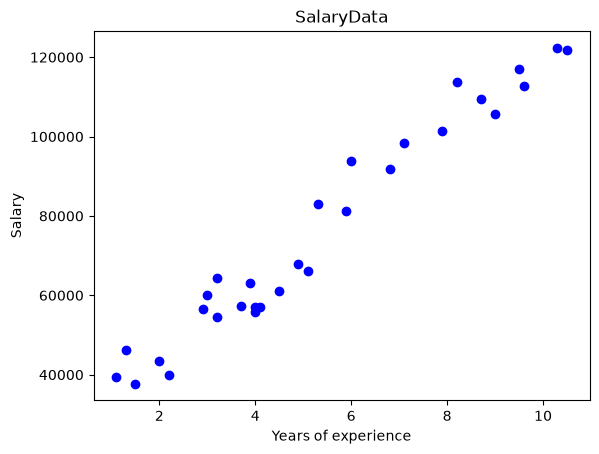

In [6]:
#split X-axis & y-axis
X=df[['YearsExperience']]
y=df['Salary']

plt.scatter(X,y, color='blue')
plt.title('SalaryData')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.show()

Evaluating datas fitness for Linear Regression by counting the correlation coefficient

In [7]:
df['YearsExperience'].corr(df['Salary'])

np.float64(0.9782416184887599)

The correlation coefficient is almost 1, indicating a nearly perfect linear relationship between years of experience and salary


## 3. Baseline Linear Regression Model

Due to the small dataset size, the model is trained on the full dataset and evaluated using Leave-One-Out cross-validation rather than a train-test split.

### Model Specification & Fitting

In [8]:
regr=linear_model.LinearRegression()

regr.fit(X,y)

y_pred=regr.predict(X)

### Parameter Interpretation (Slope & Intercept)

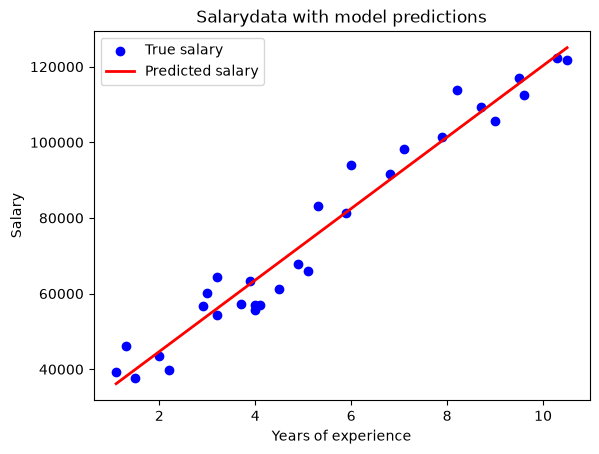

MODEL PARAMETERS

Slope: 9449.96
Intercept (c): 25792.20
Salary= 9449.96 * experience in years + 25792.20


In [9]:
plt.scatter(X, y, color='blue', label='True salary')
plt.plot(X, y_pred, color='red', linewidth=2, label='Predicted salary')
plt.title('Salarydata with model predictions')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

slope = regr.coef_[0]
intercept = regr.intercept_

print('MODEL PARAMETERS')
print(f"\nSlope: {slope:.2f}")
print(f"Intercept (c): {intercept:.2f}")
print(f"Salary= {slope:.2f} * experience in years + {intercept:.2f}")

### Performance Evaluation 

In [10]:
model_r_squared = r2_score(y, y_pred)
model_rmse = root_mean_squared_error(y,y_pred)

#LeaveOneOut CrossValidation 
loo =LeaveOneOut()
y_loocv_pred = cross_val_predict(regr,X,y,cv=loo)
rmse_loocv=root_mean_squared_error(y, y_loocv_pred)
r_squared_loocv = r2_score(y, y_loocv_pred)

print('MODEL PERFORMANCE EVALUATION')
print("\n1. Full Dataset Fit:")
print(f"R² Score: {model_r_squared:.3f}")
print(f"RMSE: {model_rmse:.2f}")
print("\n2. Leave-One-Out Cross-Validation (Generalization Performance):")
print(f"LOOCV R² Score: {r_squared_loocv:.3f}")
print(f"LOOCV RMSE: {rmse_loocv:.2f}")


MODEL PERFORMANCE EVALUATION

1. Full Dataset Fit:
R² Score: 0.957
RMSE: 5592.04

2. Leave-One-Out Cross-Validation (Generalization Performance):
LOOCV R² Score: 0.952
LOOCV RMSE: 5924.53


The model achieved strong explanatory power, which remained consistent during LOO Cross-validation. 
A small drop in R² indicates that the model is not overly sensitive to individual data points.
The minimal validation error describes good internal stability within this dataset. Due to small data size (n=30) and LOO Cross-Validation having strongly correlated training folds (size N-1), overall generalization can not be guaranteed at this point

## 4. Regression Diagnostics & LINE Assumptions

#### Linearity (Residuals vs. Fitted Plot with LOWESS)

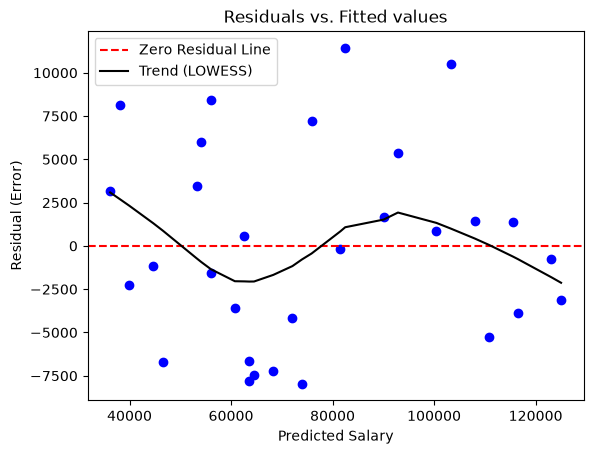

In [11]:
residuals = y-y_pred

plt.scatter(y_pred, residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--', label ='Zero Residual Line')

#creating lowess -line for trends
ax = sns.regplot(
    x=y_pred, 
    y=residuals, 
    scatter=False, 
    lowess=True, 
    line_kws={'color': 'black', 'linewidth': 1.5}
)
ax.lines[1].set_label('Trend (LOWESS)')
plt.title('Residuals vs. Fitted values')
plt.xlabel('Predicted Salary')
plt.ylabel('Residual (Error)')
plt.legend()

plt.show()

The LOWESS line in the Residuals vs. Fitted plot displays a moderate S-curve, revealing a minor systematic pattern: the model tends to overestimate salaries in the 1st and 3rd quartiles while underestimating them in the 2nd and 4th quartiles.

Taking into consideration the dataset's small size ($N = 30$), which makes the LOWESS trend highly sensitive to individual data points, and the error being relatively small (+- 3000), it is fair to say that the linearity assumption holds acceptably as a baseline. However, due to the steady shape of the S-curve, there might be an indication of a systematic error.

### Independence (Qualitative Sampling Analysis)

Because the dataset consists of cross-sectional data with no time dependency, independence is evaluated solely from a qualitative standpoint.

The commentary provided by the dataset author (below) indicates that observations were gathered through personal professional networks across various engineering disciplines.

>This set shows the relationship within engineering fields. 
>Various engineers with various years of experience have collected this data, to incorporate it into this set.

This sampling method directly violates the assumption of independent observations due to potential selection bias and unobserved clustering. Because respondents were recruited through specific networks, data points within the same engineering discipline, workplace, or geographic region are likely correlated. 

Because the dataset lacks metadata for these groupings, explicitly controlling for interdependence is not possible, and the small sample size (N = 30) prevents the use of statistical methods (e.g., hierarchical linear modeling, mixed-effects models) to infer or isolate these group effects.


### Normality of Residuals (Q-Q Plot & Shapiro-Wilk Test)

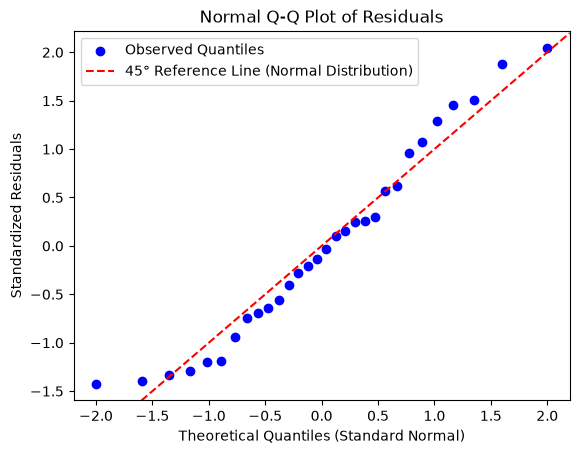

Shapiro p-value : 0.195


In [12]:
#standardize residuals & calculate theoretical quantiles for q-q-plot
std_residuals=stats.zscore(residuals)
(theoretical_quantiles, sample_quantiles), _ = stats.probplot(std_residuals, dist="norm")

plt.scatter(theoretical_quantiles,sample_quantiles,color='blue', label='Observed Quantiles')
plt.axline((0, 0), slope=1, color="red",linestyle="--",label="45° Reference Line (Normal Distribution)",)
plt.title("Normal Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles (Standard Normal)")
plt.ylabel("Standardized Residuals")
plt.legend()
plt.show()

shapiro_stat, shapiro_p = shapiro(residuals)
print(f"Shapiro p-value : {shapiro_p:.3f}")

Shapiro-Wilk p-value did not indicate any statistically significant deviation from normality, but the test's statistical power within this sample size is weak.  With the Q-Q plot showing slight right-skewness (which is expected when handling salary data), the normality assumption cannot be confirmed at this point

### Equal variance - Homoscedasticity (Scale-Location Plot & Breusch-Pagan Test)

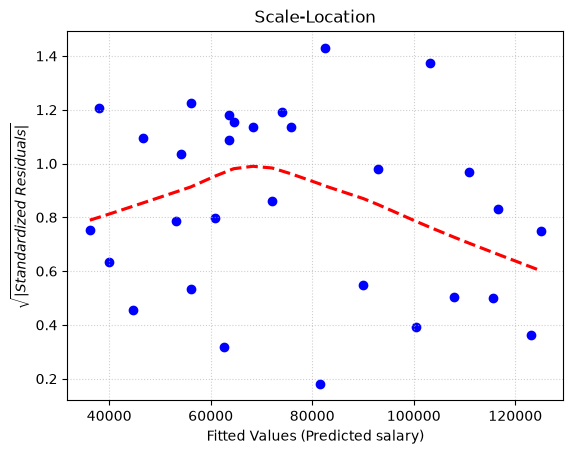


F-Test p-value: 0.543920


In [13]:
sqrt_abs_std_residuals = np.sqrt(np.abs(std_residuals))

# 2. Piirretään kuvaaja
plt.scatter(y_pred, sqrt_abs_std_residuals, color='blue')
sns.regplot(x=y_pred, y=sqrt_abs_std_residuals, scatter=False, lowess=True, line_kws={'color': 'red', 'linestyle': '--'})
plt.title('Scale-Location')
plt.xlabel('Fitted Values (Predicted salary)')
plt.ylabel(r'$\sqrt{|Standardized\ Residuals|}$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#BP -test with added constant
bp_test = het_breuschpagan(residuals, sm.add_constant(X))

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
bp_results = pd.Series(bp_test, index=labels)

bp_f_pvalue = bp_results['F-Test p-value']
print(f"\nF-Test p-value: {bp_f_pvalue:.6f}")

In the Scale-Location plot, the LOWESS curve formed a mild arch, indicating higher error variance for mid-range values. While the F-test p-value remains above 0.05, the distinct pattern in the Scale-Location plot—combined with a small sample size—suggests potential heteroscedasticity

### Conclusions

Although the model achieved strong explanatory power and consistent results in Leave-One-Out Cross-Validation, evaluation of the LINE assumptions revealed indications of systematic errors in all categories, rendering the model's predictions and statistical inferences unreliable.

To determine whether the systematic patterns in the residuals stem from noise, influential data points, or a genuine non-linear relationship between salary and experience, a deeper examination must be conducted.

####     Outlier & Influential Point Diagnosis (Cook's Distance)

In [14]:
X_design = np.c_[np.ones(len(X)), X]
n, p = X_design.shape

leverage = np.sum( X_design * np.linalg.pinv(X_design.T @ X_design).dot(X_design.T).T, axis=1)

mse = np.sum(residuals**2) / (n - p)
cooks_d = (residuals**2 / (p * mse)) * (leverage / ((1 - leverage) ** 2))

#significant D>4/n
#critical D>0.5
count_significant_deviations = np.sum((cooks_d > 4 / len(df)) & (cooks_d < 0.5))
count_critical_deviations = np.sum(cooks_d > 0.5)

print(f"Number of significant deviations : {count_significant_deviations}")
print(f"Number of critical deviations : {count_critical_deviations}")

Number of significant deviations : 0
Number of critical deviations : 0


The model does not contain individual influential points that significantly alter the slope. 

## 5. Model Redefinition & Alternative Specifications

To determine whether there is a functional form misspecification in the model and if the relationship between salary and experience is non-linear, the model will be redefined and evaluated against the original baseline model.

Due to the small dataset size (n=30), more complex solutions, such as polynomial models, were excluded to mitigate the high risk of overfitting. Instead, a stepwise transformation approach is applied to keep the model as parsimonious as possible.

###  Theoretical Motivation for Log Transformations

In empirical literature, the relationship between salary and experience is commonly specified using a log-transformed salary and a quadratic term for experience (e.g., the Mincerian earnings function). Theoretical foundations support this specification, as salary increases typically reflect relative percentage changes rather than fixed monetary increments, and variance tends to expand at higher levels of experience. Furthermore, salary growth often slows down or levels off during the final years of a career.

From a purely statistical diagnostic standpoint, testing a quadratic term on the original scale would be the conventional step to separate predictor non-linearity from response variance. However, heavily guided by economic theory, this study prioritizes the logarithmic transformation of salary first. To prevent overfitting and isolate the exact impact of each transformation, a conservative step-by-step approach is adopted: the model is initially evaluated by applying the log transformation solely to the salary variable, rather than introducing both transformations simultaneously.

Hypothetically, by dampening the impact of larger values and stabilizing their variance, the logarithmic transformation should refine the residual distribution. This is expected to flatten the S-curve in the LOWESS line (not eliminate it entirely) and resolve the right-skewness in the Q-Q plot and unequal distribution of residuals in Scale-location plot as well.

If this baseline transformation fails to show meaningful improvement in LINE assumption validation or is less sufficient in model performance metrics compared to the original baseline model, the specification will subsequently be extended by transforming the experience variable as well.

### Log-Linear Model (ln(Salary) vs. Experience)

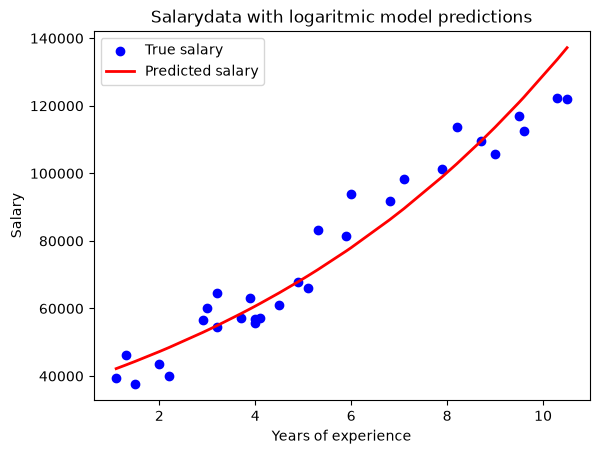

MODEL PARAMETERS

Slope (β1): 0.1255
Intercept (β0): 10.5074
ln(Salary)= 0.1255 * experience in years + 10.5074


In [15]:
log_y=np.log(y)

log_regr=linear_model.LinearRegression()
log_regr.fit(X, log_y)

log_y_pred=log_regr.predict(X)


#  Duan's smearing factor 
log_residuals = log_y - log_y_pred
duan_smearing_factor = np.mean(np.exp(log_residuals))

log_y_pred_unit_corrected = np.exp(log_y_pred) * duan_smearing_factor


plt.scatter(X, y, color='blue', label='True salary')
plt.plot(X, log_y_pred_unit_corrected, color='red', linewidth=2, label='Predicted salary')
plt.title('Salarydata with logaritmic model predictions')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

log_slope = log_regr.coef_[0]
log_intercept = log_regr.intercept_

print('MODEL PARAMETERS')
print(f"\nSlope (β1): {log_slope:.4f}")
print(f"Intercept (β0): {log_intercept:.4f}")
print(f"ln(Salary)= {log_slope:.4f} * experience in years + {log_intercept:.4f}")

### Log-Linear Performance & Assumption Verification
#### Performance

In [16]:
log_r_squared = r2_score(y, log_y_pred_unit_corrected)
log_rmse = root_mean_squared_error(y,log_y_pred_unit_corrected)

# LeaveOneOut CrossValidation with Duan's smearing factor for each fold
loo = LeaveOneOut()
log_loocv_y_pred_unit_corrected = np.zeros(len(y))

X_arr = np.asarray(X)
log_y_arr = np.asarray(log_y)

for train_idx, test_idx in loo.split(X_arr):
    log_regr.fit(X_arr[train_idx], log_y_arr[train_idx])
    
    train_res = log_y_arr[train_idx] - log_regr.predict(X_arr[train_idx])
    fold_duan_factor = np.mean(np.exp(train_res))
    
    test_log_pred = log_regr.predict(X_arr[test_idx])
    log_loocv_y_pred_unit_corrected[test_idx] = np.exp(test_log_pred) * fold_duan_factor

log_r_squared_loocv = r2_score(y, log_loocv_y_pred_unit_corrected)
log_rmse_loocv = root_mean_squared_error(y, log_loocv_y_pred_unit_corrected)

print('MODEL PERFORMANCE EVALUATION')
print("\n1. Full Dataset Fit:")
print(f"R² Score: {log_r_squared:.3f}")
print(f"RMSE: {log_rmse:.2f}")
print("\n2. Leave-One-Out Cross-Validation (Generalization Performance):")
print(f"LOOCV R² Score: {log_r_squared_loocv:.3f}")
print(f"LOOCV RMSE: {log_rmse_loocv:.2f}")

MODEL PERFORMANCE EVALUATION

1. Full Dataset Fit:
R² Score: 0.928
RMSE: 7249.85

2. Leave-One-Out Cross-Validation (Generalization Performance):
LOOCV R² Score: 0.914
LOOCV RMSE: 7899.37


#### Linearity

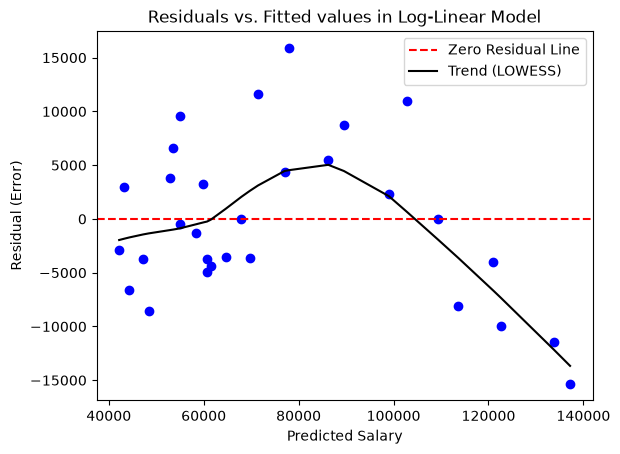

In [17]:
log_residuals = y-log_y_pred_unit_corrected

plt.scatter(log_y_pred_unit_corrected, log_residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--', label ='Zero Residual Line')

#creating lowess -line for trends
ax = sns.regplot(
    x=log_y_pred_unit_corrected, 
    y=log_residuals, 
    scatter=False, 
    lowess=True, 
    line_kws={'color': 'black', 'linewidth': 1.5}
)
ax.lines[1].set_label('Trend (LOWESS)')
plt.title('Residuals vs. Fitted values in Log-Linear Model')
plt.xlabel('Predicted Salary')
plt.ylabel('Residual (Error)')
plt.legend()
plt.show()


#### Normality

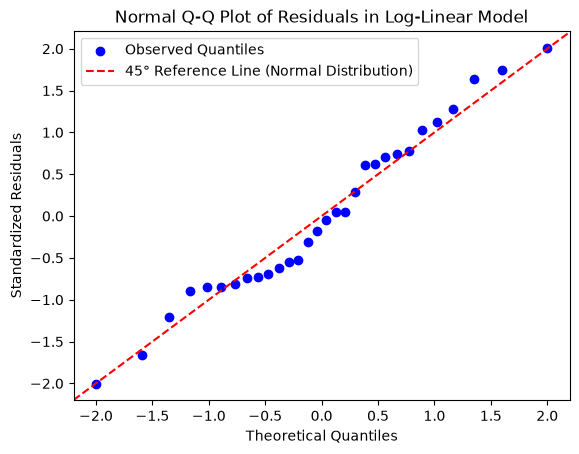

Shapiro p-value : 0.545


In [18]:
# Normality of residuals must be evaluated on the log scale (ln(y) - ln(y_pred)), 
# because log-linear models assume normally distributed errors 
# in the log domain rather than in original currency units.

log_scale_residuals = log_y - log_y_pred
log_std_residuals=stats.zscore(log_scale_residuals)
(log_theoretical_quantiles, log_sample_quantiles), _ = stats.probplot(log_std_residuals, dist="norm")

plt.scatter(log_theoretical_quantiles,log_sample_quantiles,color='blue', label='Observed Quantiles')
plt.axline((0, 0), slope=1, color="red",linestyle="--",label="45° Reference Line (Normal Distribution)",)
plt.title("Normal Q-Q Plot of Residuals in Log-Linear Model")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.legend()
plt.show()

log_shapiro_stat, log_shapiro_p = shapiro(log_scale_residuals)
print(f"Shapiro p-value : {log_shapiro_p:.3f}")

#### Equal variance - Homoscedasticity

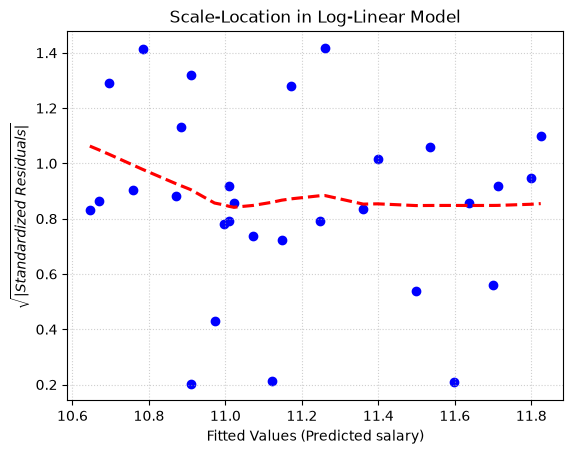


F-Test p-value: 0.323677


In [19]:
log_sqrt_abs_std_residuals = np.sqrt(np.abs(log_std_residuals))

plt.scatter(log_y_pred, log_sqrt_abs_std_residuals, color='blue')
sns.regplot(x=log_y_pred, y=log_sqrt_abs_std_residuals, scatter=False, lowess=True, line_kws={'color': 'red', 'linestyle': '--'})
plt.title('Scale-Location in Log-Linear Model')
plt.xlabel('Fitted Values (Predicted salary)')
plt.ylabel(r'$\sqrt{|Standardized\ Residuals|}$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#BP -test with added constant
log_bp_test = het_breuschpagan(log_scale_residuals, sm.add_constant(X))

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
log_bp_results = pd.Series(log_bp_test, index=labels)

log_bp_f_pvalue = log_bp_results['F-Test p-value']
print(f"\nF-Test p-value: {log_bp_f_pvalue:.6f}")

#### Conclusions of Log-Linear Model
Similar to the baseline model, the log-linear model showed strong explanatory power and consistent performance in LOO cross-validation. Log-linear model produced a slightly lower R² score (calculated on the back-transformed scale to ensure direct comparability with the baseline model).

Evaluating the LINE assumptions showed that log-transforming salary created mixed results rather than the expected overall improvement
* Contrary to the hypothesis, the LOWESS curve in the Residuals vs. Fitted plot shifted from a mild S-curve to a more pronounced U-shape
* As hypothesized, the Q-Q plot improved, showing better alignment along the normal line with reduced right-skewness. Additionally, homoscedasticity improved by showing a more level and uniform spread of residuals in the Scale-Location plot.

While log-transforming salary addressed non-normality and heteroscedasticity, it compromised model fit and linearity. This U-shaped pattern in the residuals strongly suggests that the relationship between experience and salary deviates from a simple log-linear trend

###   Theoretical Motivation for Log Log-Quadratic transformation

To ensure reliable model performance, the linearity assumption must hold. The U-shaped residual pattern indicated that a simple log-linear specification was insufficient, requiring a model that better captures the true underlying relationship between experience and salary.

As outlined in our model redefinition plan, since the log-linear model failed to improve LINE diagnostics, we move forward by introducing a quadratic term for experience,  guided by labor economics theory.

### Log-Quadratic Model (ln(Salary) vs. Experience + Experience²)


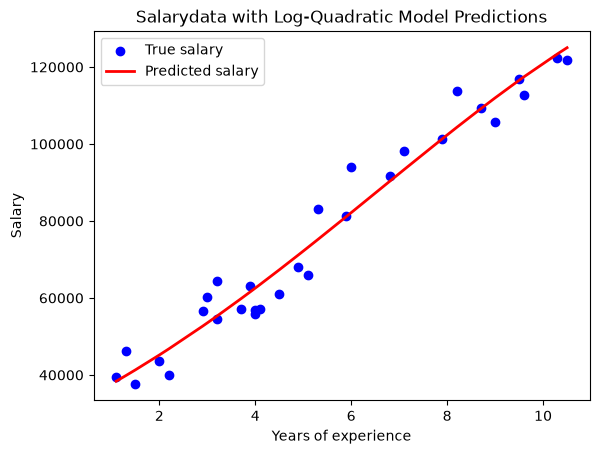

MODEL PARAMETERS

Intercept (β0): 10.3369
Slope X   (β1): 0.2024
Slope X²  (β2): -0.0066
ln(Salary) = 0.2024 * experience + -0.0066 * experience² + 10.3369


In [20]:
sq_X = np.hstack([X, X**2])

sq_log_regr=linear_model.LinearRegression()
sq_log_regr.fit(sq_X, log_y)

sq_log_y_pred=sq_log_regr.predict(sq_X)

# Converting to original units 
#  Duan's smearing factor 
sq_log_residuals = log_y - sq_log_y_pred
duan_smearing_factor = np.mean(np.exp(sq_log_residuals))

sq_log_y_pred_unit_corrected = np.exp(sq_log_y_pred) * duan_smearing_factor


plt.scatter(X, y, color='blue', label='True salary')
plt.plot(X, sq_log_y_pred_unit_corrected, color='red', linewidth=2, label='Predicted salary')
plt.title('Salarydata with Log-Quadratic Model Predictions')
plt.xlabel('Years of experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

sq_log_beta1 = sq_log_regr.coef_[0]    
sq_log_beta2 = sq_log_regr.coef_[1]     
sq_log_intercept = sq_log_regr.intercept_  

print('MODEL PARAMETERS')
print(f"\nIntercept (β0): {sq_log_intercept:.4f}")
print(f"Slope X   (β1): {sq_log_beta1:.4f}")
print(f"Slope X²  (β2): {sq_log_beta2:.4f}")
print(f"ln(Salary) = {sq_log_beta1:.4f} * experience + {sq_log_beta2:.4f} * experience² + {sq_log_intercept:.4f}")

### Log-Quadritic Perfomance & Assumption Verification
#### Performance

In [ ]:
n = len(y)
p = sq_X.shape[1]

sq_log_r_squared = r2_score(y, sq_log_y_pred_unit_corrected)
sq_log_adj_r_squared = 1 - (1 - sq_log_r_squared) * (n - 1) / (n - p - 1)
sq_log_rmse = root_mean_squared_error(y,sq_log_y_pred_unit_corrected)

# LeaveOneOut CrossValidation with Duan's smearing factor for each fold
loo = LeaveOneOut()
sq_log_loocv_y_pred_unit_corrected = np.zeros(len(y))

sq_X_arr = np.asarray(sq_X)

for train_idx, test_idx in loo.split(sq_X_arr):
    sq_log_regr.fit(sq_X_arr[train_idx], log_y_arr[train_idx])
    
    sq_train_res = log_y_arr[train_idx] - sq_log_regr.predict(sq_X_arr[train_idx])
    sq_fold_duan_factor = np.mean(np.exp(sq_train_res))
    
    sq_test_log_pred = sq_log_regr.predict(sq_X_arr[test_idx])
    sq_log_loocv_y_pred_unit_corrected[test_idx] = np.exp(sq_test_log_pred) * sq_fold_duan_factor

sq_log_r_squared_loocv = r2_score(y, sq_log_loocv_y_pred_unit_corrected)
sq_log_adj_r_squared_loocv = 1 - (1 - sq_log_r_squared_loocv) * (n - 1) / (n - p - 1)
sq_log_rmse_loocv = root_mean_squared_error(y, sq_log_loocv_y_pred_unit_corrected)

print('MODEL PERFORMANCE EVALUATION')
print("\n1. Full Dataset Fit:")
print(f"R² Score: {sq_log_r_squared:.3f}")
print(f"Adjusted R² Score: {sq_log_adj_r_squared:.3f}")
print(f"RMSE: {sq_log_rmse:.2f}")
print("\n2. Leave-One-Out Cross-Validation:")
print(f"LOOCV R² Score: {sq_log_r_squared_loocv:.3f}")
print(f"LOOCV Adjusted R² Score: {sq_log_adj_r_squared_loocv:.3f}")
print(f"LOOCV RMSE: {sq_log_rmse_loocv:.2f}")

MODEL PERFORMANCE EVALUATION

1. Full Dataset Fit:
R² Score: 0.960
Adjusted R² Score: 0.957
RMSE: 5388.12

2. Leave-One-Out Cross-Validation:
LOOCV R² Score: 0.952
LOOCV Adjusted R² Score: 0.949
LOOCV RMSE: 5878.78


#### Linearity

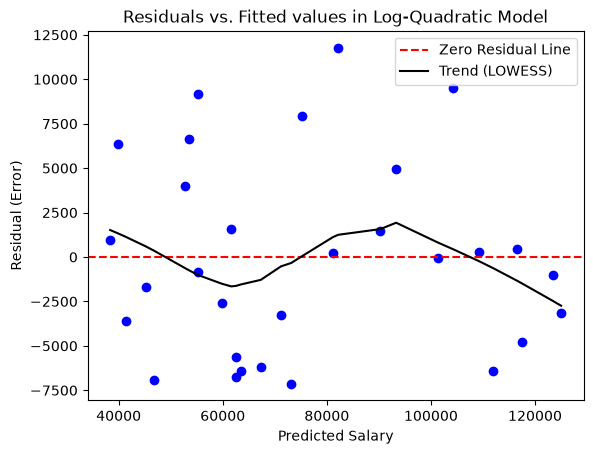

In [22]:
sq_log_residuals = y-sq_log_y_pred_unit_corrected

plt.scatter(sq_log_y_pred_unit_corrected, sq_log_residuals, color='blue')
plt.axhline(y=0, color='red', linestyle='--', label ='Zero Residual Line')

#creating lowess -line for trends
ax = sns.regplot(
    x=sq_log_y_pred_unit_corrected, 
    y=sq_log_residuals, 
    scatter=False, 
    lowess=True, 
    line_kws={'color': 'black', 'linewidth': 1.5}
)
ax.lines[1].set_label('Trend (LOWESS)')
plt.title('Residuals vs. Fitted values in Log-Quadratic Model')
plt.xlabel('Predicted Salary')
plt.ylabel('Residual (Error)')
plt.legend()
plt.show()


#### Normality

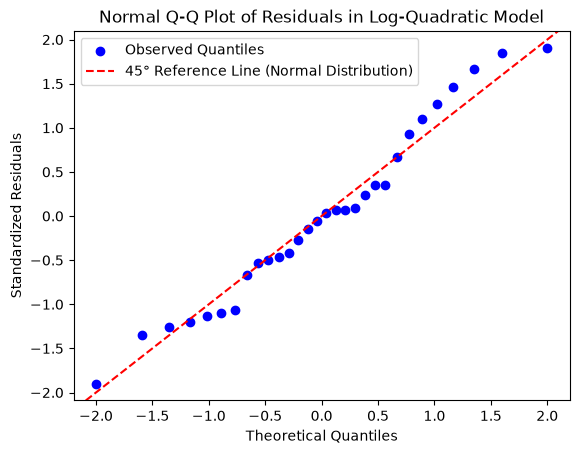

Shapiro p-value : 0.444


In [23]:
sq_log_scale_residuals = log_y - sq_log_y_pred
sq_log_std_residuals=stats.zscore(sq_log_scale_residuals)
(sq_log_theoretical_quantiles, sq_log_sample_quantiles), _ = stats.probplot(sq_log_std_residuals, dist="norm")

plt.scatter(sq_log_theoretical_quantiles,sq_log_sample_quantiles,color='blue', label='Observed Quantiles')
plt.axline((0, 0), slope=1, color="red",linestyle="--",label="45° Reference Line (Normal Distribution)",)
plt.title("Normal Q-Q Plot of Residuals in Log-Quadratic Model")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Standardized Residuals")
plt.legend()
plt.show()

sq_log_shapiro_stat, sq_log_shapiro_p = shapiro(sq_log_scale_residuals)
print(f"Shapiro p-value : {sq_log_shapiro_p:.3f}")

#### Equal Variance - Homoscedasticity

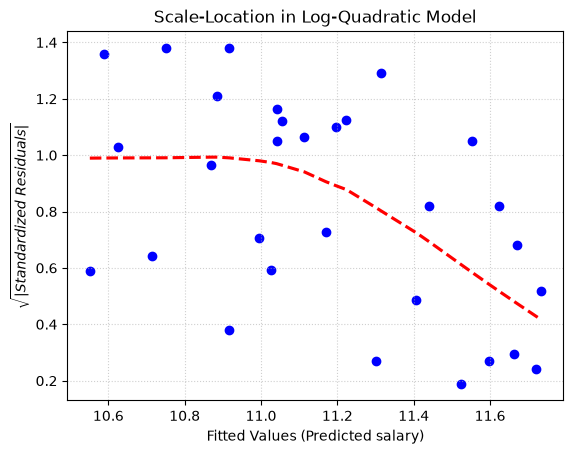


 F-Test p-value: 0.036808


In [24]:
sq_log_sqrt_abs_std_residuals = np.sqrt(np.abs(sq_log_std_residuals))

plt.scatter(sq_log_y_pred, sq_log_sqrt_abs_std_residuals, color='blue')
sns.regplot(x=sq_log_y_pred, y=sq_log_sqrt_abs_std_residuals, scatter=False, lowess=True, line_kws={'color': 'red', 'linestyle': '--'})
plt.title('Scale-Location in Log-Quadratic Model')
plt.xlabel('Fitted Values (Predicted salary)')
plt.ylabel(r'$\sqrt{|Standardized\ Residuals|}$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#BP -test with added constant
sq_log_bp_test = het_breuschpagan(sq_log_scale_residuals, sm.add_constant(sq_X))

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
sq_log_bp_results = pd.Series(sq_log_bp_test, index=labels)

sq_log_bp_f_pvalue = sq_log_bp_results['F-Test p-value']
print(f"\n F-Test p-value: {sq_log_bp_f_pvalue:.6f}")

### Conclusions of Log-Quadratic Model

Like the previous models, the log-quadratic model demonstrated consistent performance through leave-one-out cross-validation. Its explanatory power was equal to that of the baseline model (and slightly higher prior to rounding), accompanied by a lower RMSE, which indicates marginally better overall performance.

The log-quadratic model brought improvements to some LINE assumptions. A mild S-curve appeared to the Residuals vs. Fitted plot, but it was not as pronounced as in the baseline model. The Q-Q plot is nearly identical to the log-linear model's and have no distinct pattern compared to the baseline model. However, the LOWESS curve in the Scale-Location plot dipped sharply on the right side and the the F-test p-value of 0.037 confirms heteroscedasticity. Heteroscedasticity also makes Duan's smearing factor unreliable, as it assumes that error terms are homoscedastic.


## 6. Comparative Model Analysis & Synthesis
### Model summaries

In [25]:
#creating summary data

columns = ["Baseline model", "Log-Linear Model", "Log-Quadratic Model"]

rows = [ "(Adjusted) R²",
        "(Adjusted) LOO-CV R²",
        "RMSE", 
        "LOO-CV RMSE",
        "Residuals vs. Fitted -plot", 
        "Q-Q -plot", 
        "Shapiro p-value",
        "Scale-Location plot",
        "F-Test p-value"]
data = [
[model_r_squared, log_r_squared, sq_log_adj_r_squared],
[r_squared_loocv, log_r_squared_loocv, sq_log_adj_r_squared_loocv],
[model_rmse, log_rmse, sq_log_rmse],
[rmse_loocv, log_rmse_loocv, sq_log_rmse_loocv],
["Slight non-linear trend", "Pronounced quadratic pattern", "Nearly linear (minimal curvature)"],
["Right-skewed residuals", "Approximately normal", "Approximately normal"],
[shapiro_p, log_shapiro_p, sq_log_shapiro_p],
["Slight variance arch", "Near-homoscedastic (minor left-tail spike)", "Heteroscedastic (rightward dip)"],
[bp_f_pvalue, log_bp_f_pvalue, sq_log_bp_f_pvalue]
]

summary_perf = pd.DataFrame(data, index=rows, columns=columns)

# choosing best values

def highlight_best(data):
    """
    Funktio, joka korostaa valitut "parhaat" solut vihreällä.
    Muokkaa 'best_cells' -listaan (rivi, sarake) -koordinaatit.
    """

    best_cells = [
        ("(Adjusted) R²","Log-Quadratic Model"),
        ("(Adjusted) LOO-CV R²","Log-Quadratic Model"),
        ("RMSE", "Log-Quadratic Model"),
        ("LOO-CV RMSE","Log-Quadratic Model"),
        ("Residuals vs. Fitted -plot","Log-Quadratic Model"), 
        ("Q-Q -plot", "Log-Linear Model"),
        ("Q-Q -plot", "Log-Quadratic Model"),
        ("Shapiro p-value","Baseline model"),
        ("Shapiro p-value","Log-Linear Model"),
        ("Shapiro p-value","Log-Quadratic Model"),
        ("Scale-Location plot","Log-Linear Model"),
        ("F-Test p-value","Baseline model"),
        ("F-Test p-value","Log-Linear Model")

]
    
    df_style = pd.DataFrame('', index=data.index, columns=data.columns)
    for row, col in best_cells:
        df_style.loc[row, col] = 'background-color: #c8e6c9; font-weight: bold;'
    return df_style

#creating style
styled_summary = (
    summary_perf.style
    .apply(highlight_best, axis=None)
    .set_table_styles(
        [
            
            {"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold"), ("padding", "8px")]},
            {"selector": "td", "props": [("text-align", "center"), ("padding", "6px")]},
        ]
    )
    .set_properties(**{"background-color": "#f9f9f9", "color": "#333", "border-color": "#F9F9F9"})
    .set_caption("Performance and Line Assumptions Comparison Summary")
)


display(styled_summary)

,Baseline model,Log-Linear Model,Log-Quadratic Model
(Adjusted) R²,0.956957,0.927653,0.957079
(Adjusted) LOO-CV R²,0.951686,0.914109,0.948906
RMSE,5592.043609,7249.845396,5388.118827
LOO-CV RMSE,5924.534687,7899.372155,5878.781389
Residuals vs. Fitted -plot,Slight non-linear trend,Pronounced quadratic pattern,Nearly linear (minimal curvature)
Q-Q -plot,Right-skewed residuals,Approximately normal,Approximately normal
Shapiro p-value,0.195222,0.544623,0.443951
Scale-Location plot,Slight variance arch,Near-homoscedastic (minor left-tail spike),Heteroscedastic (rightward dip)
F-Test p-value,0.543920,0.323677,0.036808


### 7. Model Selection and Justification

In model selection, we prioritize models that accurately reflect the underlying data structure, demonstrate generalizability, and allow for reliable performance evaluation. Due to the small sample size, formal diagnostic tests suffer from low statistical power when evaluating linear regression assumptions. Consequently, rather than relying strictly on statistical metrics, greater emphasis was placed on the visual analysis of residual plots. In visual diagnostics, given the sample size, distinguishing between random noise, weak uninformative signals, and systematic model misspecification proved challenging. To prevent the overinterpretation of a single plot, a more holistic approach to evaluating overall patterns was taken.

Among the candidate models, the log-linear model exhibited the lowest explanatory power and clear evidence of non-linearity. It was therefore rejected, narrowing the final comparison down to the baseline model and the log-quadratic model. Both models produced strong explanatory power and nearly identical RMSE values, both of which remained consistent across Leave-One-Out cross-validation.

When reviewing the core regression assumptions for the baseline model, individual diagnostic plots displayed only minor, subtle signs of non-compliance. Small deviations recurred consistently across every diagnostic view and their collective pattern strongly suggests a fundamental model misspecification. 

In contrast, the log-quadratic model fulfills the most critical linearity assumption, but exhibits heteroscedastic error variance. This heteroscedasticity is structurally explainable: in small samples, polynomial models are prone to high leverage at extreme values, and the previously established potential unobserved clustering could further exacerbate this dispersion.

Although the small sample size and data collection constraints favor a simpler model, the advantages of the log-quadratic model are evident. The log-quadratic model captures the underlying relationship between variables substantially better and rests on a strong theoretical foundation, which hypothetically enhances its out-of-sample generalizability.

At this stage, the log-quadratic model is conditionally selected. Heteroscedasticity is addressed by evaluating p-values using HC3 robust standard errors. The log-quadratic model will be finalized only if the quadratic term remains statistically significant following the HC3 adjustment. If the quadratic term loses significance, we revert to the more parsimonious baseline model to avoid overfitting.

#### Log-Quadratic Model's $p$-value and 95% Confidence Interval

In [30]:
X_design = sm.add_constant(sq_X)  

model = sm.OLS(log_y, X_design)
#HC3 robust standard errors
results = model.fit(cov_type='HC3')

print(results.summary())

quad_ci = results.conf_int(alpha=0.05).iloc[2].values

print(f"p-value: {results.pvalues.iloc[2]:.4f}")
print(f"95% CI: [{quad_ci[0]:.4f}, {quad_ci[1]:.4f}]")

                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.949
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     341.6
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           6.75e-20
Time:                        09:38:27   Log-Likelihood:                 32.391
No. Observations:                  30   AIC:                            -58.78
Df Residuals:                      27   BIC:                            -54.58
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.3369      0.087    119.255      0.0

The quadratic experience term is statistically significant (p < 0.01$, HC3 robust SEs). Its negative confidence interval [-0.0113, -0.0020] captures the expected slowing rate of salary growth as work experience increases. The log-quadratic model is selected as the final, best-performing specification

###  Model Limitations & Scope of Generalization

While log-quadritic model procvides the best fit for data, several limitations must be taken to consideration when interpreting results. First, the quadratic specification can project unrealistic salary declines if extrapolated beyond the observed experience range. Second, omitting key variables such as education, position, and location increases individual prediction uncertainty, despite capturing aggregate trends well. Finally, given the small sample size and localized data, parameter estimates should be generalized cautiously to other labor markets or professions.